# Aftershock v1
Forecasting how much the S&P 500 will move over the next 5 trading days.
We predict the *size* of price movements (volatility), not their direction.



In [52]:
# --- Tools for this project ---------------------------------------------
import pandas as pd               # tables with dates: our main data structure
import numpy as np                # fast math: logs, square roots, averages
import matplotlib.pyplot as plt   # charts
import sklearn                    # scikit-learn: gives us the HAR model (a straight-line formula)
import lightgbm                   # LightGBM: our machine learning model (many small decision trees)
import yfinance as yf             # downloads free market prices from Yahoo Finance

# --- Check that every tool loaded, and record its version ----------------
for lib in [pd, np, sklearn, lightgbm, yf]:   # go through each library in turn
    print(f"{lib.__name__:<10} {lib.__version__}")   # print its name and version number


pandas     2.2.3
numpy      2.1.3
sklearn    1.6.1
lightgbm   4.6.0
yfinance   0.2.66


The S&P 500 is a list of 500 large US companies. People use it as a picture of "the US stock market".
SPY is a fund you can buy like a single share. It holds all 500 companies, so its price follows the S&P 500. It started trading on 29 January 1993, which is why our data starts on that day.
Dividends. Many companies pay shareholders a small amount of cash a few times a year, and SPY passes it on. On the day the cash is paid out, the price drops by about that amount. That drop is not a real market move: the money just moved from the fund to your pocket. If we left those drops in, our model would think the market moved when it didn't.
Adjusted prices. auto_adjust=True tells Yahoo to correct the whole price history for dividends (and share splits). After this correction, the price changes show only real market moves. That's what we want.


## 1. Get the data
We download daily SPY prices, adjusted for dividends, from its first trading day (1993-01-29) to today.






In [53]:
# --- Download daily SPY prices from Yahoo Finance --------------------------
raw = yf.download(
    "SPY",                    # the ticker: the fund that follows the S&P 500
    start="1993-01-29",       # SPY's first trading day
    auto_adjust=True,         # correct prices for dividends and splits
    progress=False,           # hide the download progress bar
)

# --- Keep only the daily closing price --------------------------------------
prices = raw["Close"].squeeze()   # one column of closing prices; squeeze() turns it into a simple Series
prices = prices.dropna()          # remove any day with a missing price
prices.name = "price"             # give the Series a clear name

# --- First look ------------------------------------------------------------
print(prices.head(3))                                 # first 3 days
print(prices.tail(3))                                 # last 3 days
print("Rows:", len(prices))                           # number of trading days
print("Missing values:", prices.isna().sum())         # should be 0


Date
1993-01-29    24.053530
1993-02-01    24.224611
1993-02-02    24.275925
Name: price, dtype: float64
Date
2026-09-30    762.630005
2026-10-01    763.989990
2026-10-02    769.640015
Name: price, dtype: float64
Rows: 8477
Missing values: 0


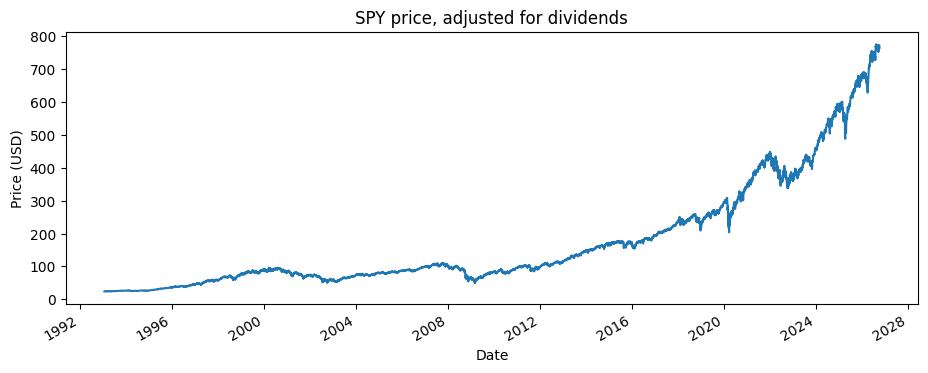

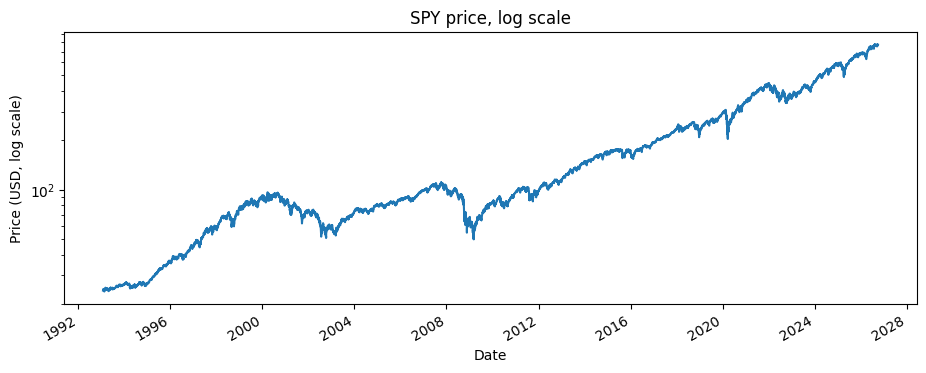

In [54]:
# --- Chart the full price history -------------------------------------------
ax = prices.plot(figsize=(11, 4), title="SPY price, adjusted for dividends")   # line chart: date vs price
ax.set_ylabel("Price (USD)")   # label the vertical axis
plt.show()                     # draw the chart

# --- Same chart on a log scale ----------------------------------------------
ax = prices.plot(figsize=(11, 4), logy=True, title="SPY price, log scale")     # log scale: equal % moves look equal in height
ax.set_ylabel("Price (USD, log scale)")
plt.show()

## 2. Returns and target
Daily log returns, then the target: annualized volatility over the next 5 trading days.


In [55]:
# --- Safety check: stop here if the price data looks wrong ------------------
assert str(prices.index[0].date()) == "1993-01-29", "First date should be 1993-01-29"   # correct start date
assert len(prices) > 8000, "Expected more than 8,000 trading days"                         # enough history
assert prices.isna().sum() == 0, "There are missing prices"                               # no gaps
print("Prices look good:", len(prices), "days, from", prices.index[0].date(), "to", prices.index[-1].date())


Prices look good: 8477 days, from 1993-01-29 to 2026-10-02


In [56]:
H = 5   # forecast horizon: we forecast volatility over the next 5 trading days

df = pd.DataFrame({"price": prices})               # one table to hold everything, indexed by date
df["r"] = np.log(df["price"] / df["price"].shift(1))   # log return: today's price vs yesterday's (shift(1) = yesterday)
df["r2"] = df["r"] ** 2                             # squared return: the size of the move, always positive

print(df.head(3))   # the first row has no return, because there is no "yesterday" for day one


                price         r        r2
Date                                     
1993-01-29  24.053530       NaN       NaN
1993-02-01  24.224611  0.007087  0.000050
1993-02-02  24.275925  0.002116  0.000004


In [57]:
# --- Sum of squared returns over the NEXT 5 days ----------------------------
future_sum = df["r2"].rolling(H).sum().shift(-H)    # rolling(H) adds the last 5 days; shift(-H) moves that sum back 5 rows,
                                                    # so on day t it holds days t+1 ... t+5 (the future)

# --- Turn it into yearly volatility ---------------------------------------
df["target_vol"] = np.sqrt(252 / H * future_sum)    # average daily squared move × 252 days, then square root
df["target"] = np.log(df["target_vol"])             # the log of the target: what the models will actually learn

print(df[["price", "r", "target_vol"]].tail(7))     # the last 5 rows show NaN: their future is not known yet


                 price         r  target_vol
Date                                        
2026-09-24  767.179993 -0.000821    0.069550
2026-09-25  771.349976  0.005421    0.078054
2026-09-28  765.609985 -0.007469         NaN
2026-09-29  764.200012 -0.001843         NaN
2026-09-30  762.630005 -0.002057         NaN
2026-10-01  763.989990  0.001782         NaN
2026-10-02  769.640015  0.007368         NaN


In [58]:
i = 100                                              # pick any row in the middle, e.g. row 100
next5 = df["r"].iloc[i + 1 : i + 1 + H]              # the 5 returns AFTER row i (days t+1 ... t+5)
by_hand = np.sqrt(252 / H * (next5 ** 2).sum())      # same formula, written out by hand
by_code = df["target_vol"].iloc[i]                   # what our vectorised code computed

print(f"by hand: {by_hand:.6f}   by code: {by_code:.6f}")   # show both numbers
assert np.isclose(by_hand, by_code), "Target does not match the hand calculation"   # stop if they differ


by hand: 0.128019   by code: 0.128019


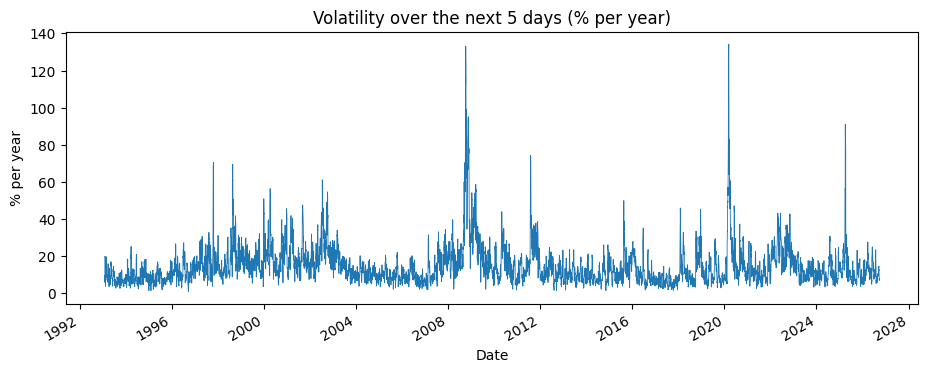

Average: 15.0 %
Highest: 134.2 % on 2020-03-11


In [59]:
ax = (df["target_vol"] * 100).plot(figsize=(11, 4), linewidth=0.6,
                                   title="Volatility over the next 5 days (% per year)")   # ×100 to show percent
ax.set_ylabel("% per year")   # label the vertical axis
plt.show()                    # draw the chart

print("Average:", round(df["target_vol"].mean() * 100, 1), "%")    # typical level
print("Highest:", round(df["target_vol"].max() * 100, 1), "% on", df["target_vol"].idxmax().date())   # worst week


## 3. Inputs (features)
Four clues per day, each using only information known at the end of that day:
volatility over the last 1, 5 and 22 days (log), and today's return.


In [60]:
# --- Safety check: stop here if Lesson 3's table looks wrong ----------------
assert {"r", "r2", "target_vol", "target"} <= set(df.columns), "Run Lesson 3 first"   # all columns exist
assert df["target_vol"].tail(H).isna().all(), "The last 5 targets should be empty"     # no future peeking
avg = df["target_vol"].mean() * 100                                                    # average volatility, in %
assert 10 < avg < 25, f"Average volatility looks odd: {avg:.1f}%"                       # sensible range for SPY
print(f"looks good. Average volatility: {avg:.1f}% per year")


looks good. Average volatility: 15.0% per year


In [61]:
TINY = 1e-4   # a floor value: a few days have a return of exactly 0, and log(0) is not allowed

FEATURES = ["vol_1d", "vol_5d", "vol_22d", "ret_1d"]   # the names of our four inputs, used everywhere later

def past_vol(r2, n):
    """Yearly volatility over the last n days, INCLUDING today (looks backward only)."""
    return np.sqrt(252 / n * r2.rolling(n).sum())   # same recipe as the target, but over the past n days

def make_features(table):
    """Build the four inputs from a table that has columns 'r' and 'r2'."""
    out = pd.DataFrame(index=table.index)                                   # empty table with the same dates
    out["vol_1d"]  = np.log(past_vol(table["r2"], 1).clip(lower=TINY))      # today's move (log)
    out["vol_5d"]  = np.log(past_vol(table["r2"], 5).clip(lower=TINY))      # last week (log)
    out["vol_22d"] = np.log(past_vol(table["r2"], 22).clip(lower=TINY))     # last month (log)
    out["ret_1d"]  = table["r"]                                             # today's return, sign kept
    return out

df[FEATURES] = make_features(df)            # add the four inputs to our main table
print(df[FEATURES].tail(3).round(3))        # look at the latest values


            vol_1d  vol_5d  vol_22d  ret_1d
Date                                       
2026-09-30  -3.422  -2.679   -2.270  -0.002
2026-10-01  -3.565  -2.666   -2.273   0.002
2026-10-02  -2.146  -2.550   -2.270   0.007


In [62]:
data = df.dropna(subset=FEATURES + ["target"]).copy()   # drop rows where any input or the target is missing
                                                        # this removes the first 22 days (not enough history for vol_22d)
                                                        # and the last 5 days (their future is not known yet)

print("Rows before:", len(df), "  Rows after:", len(data))        # we should lose about 27 rows
print(data[FEATURES + ["target"]].describe().round(3))            # summary: count, mean, min, max of each column


Rows before: 8477   Rows after: 8450
         vol_1d    vol_5d   vol_22d    ret_1d    target
count  8450.000  8450.000  8450.000  8450.000  8450.000
mean     -2.691    -2.090    -1.975     0.000    -2.090
std       1.320     0.612     0.484     0.012     0.612
min      -9.210    -4.711    -3.291    -0.116    -4.711
25%      -3.341    -2.502    -2.323    -0.004    -2.503
50%      -2.470    -2.096    -2.021     0.001    -2.096
75%      -1.805    -1.686    -1.659     0.006    -1.687
max       0.767     0.294    -0.069     0.136     0.294


In [63]:
k = 5000                                              # pick a day in the middle of the history
cut_day = df.index[k]                                 # the date of that day
short = df.loc[:cut_day, ["r", "r2"]]                 # history ENDING on cut_day: the future is deleted

with_future    = make_features(df).loc[cut_day]       # inputs built when the future was available
without_future = make_features(short).loc[cut_day]    # inputs built with no future at all

print(pd.DataFrame({"with future": with_future, "without future": without_future}).round(6))   # side by side
assert np.allclose(with_future, without_future), "LEAK: an input uses future data!"            # must be identical
print("No leakage: inputs on", cut_day.date(), "use only the past.")


         with future  without future
vol_1d     -3.572774       -3.572774
vol_5d     -2.979771       -2.979771
vol_22d    -1.970350       -1.970350
ret_1d      0.001769        0.001769
No leakage: inputs on 2012-12-05 use only the past.


## 4. Models
Three guessers with the same interface (fit, predict), all working in log volatility:
Naive (last week), HAR (straight-line formula, Corsi 2009), LightGBM (many small decision trees).


In [64]:
# --- Safety check: stop here if Lesson 4's table looks wrong ----------------
assert set(FEATURES) <= set(data.columns), "Run Lesson 4 first"                  # all four inputs exist
assert data[FEATURES + ["target"]].notna().all().all(), "data has missing values"   # clean table, no gaps
print(f"looks good: {len(data)} rows, from {data.index[0].date()} to {data.index[-1].date()}")


looks good: 8450 rows, from 1993-03-03 to 2026-09-25


In [65]:
from sklearn.linear_model import LinearRegression   # finds the best straight-line weights
from lightgbm import LGBMRegressor                  # many small decision trees, each fixing earlier mistakes

class Naive:
    """Guess: next week's volatility = last week's volatility."""
    def fit(self, X, y):
        return self                                 # nothing to learn
    def predict(self, X):
        return X["vol_5d"].values                   # last week's (log) volatility is the guess

class HAR:
    """Straight-line mix of today's, last week's and last month's volatility (Corsi, 2009)."""
    cols = ["vol_1d", "vol_5d", "vol_22d"]          # HAR uses only the three volatility inputs
    def fit(self, X, y):
        self.model = LinearRegression()             # create an empty straight-line model
        self.model.fit(X[self.cols], y)             # learn the best weights b0..b3 from past rows
        return self
    def predict(self, X):
        return self.model.predict(X[self.cols])     # apply the learned recipe to new rows

class LGBM:
    """Machine learning: hundreds of small decision trees on all four inputs."""
    def fit(self, X, y):
        self.model = LGBMRegressor(
            n_estimators=300,     # number of trees
            learning_rate=0.03,   # how big a step each new tree takes (small = careful)
            num_leaves=15,        # how many final answers each tree can have (small = simple trees)
            random_state=42,      # fixed seed: same result every time we run
            verbose=-1,           # hide training messages
        )
        self.model.fit(X[FEATURES], y)              # learn from all four inputs
        return self
    def predict(self, X):
        return self.model.predict(X[FEATURES])      # guess for new rows

MODELS = {"Naive": Naive, "HAR": HAR, "LightGBM": LGBM}   # a dictionary: name -> model, so we can loop over them
print("Models ready:", list(MODELS))


Models ready: ['Naive', 'HAR', 'LightGBM']


In [66]:
half = len(data) // 2                       # index of the middle row
X, y = data[FEATURES], data["target"]       # X = clues, y = correct answers

for name, Model in MODELS.items():          # loop over the three models
    m = Model().fit(X.iloc[:half], y.iloc[:half])            # learn from the first half only
    guess = np.exp(m.predict(X.iloc[half:half + 3])) * 100   # guess 3 new days; exp() undoes the log; ×100 for %
    print(f"{name:<9}", guess.round(1), "% per year")        # show the three guesses

actual = np.exp(y.iloc[half:half + 3].values) * 100          # what really happened on those 3 days
print(f"{'Actual':<9}", actual.round(1), "% per year")


Naive     [10.6 10.9 10.2] % per year
HAR       [12.9 12.9 11.6] % per year
LightGBM  [14.7 11.9 12.3] % per year
Actual    [ 8.1  7.8 10.9] % per year


In [67]:
har = HAR().fit(X.iloc[:half], y.iloc[:half])                    # learn HAR on the first half again
weights = pd.Series(har.model.coef_, index=HAR.cols).round(3)    # the learned weights b1, b2, b3
print(weights)                                                   # how much each time span matters
print("b0 (starting value):", round(har.model.intercept_, 3))    # the constant in the formula


vol_1d     0.005
vol_5d     0.151
vol_22d    0.688
dtype: float64
b0 (starting value): -0.379


## 5. Walk-forward test
Each year from 2005: learn from all earlier history (expanding window), minus a 5-day gap
so no training answer reaches into the test year, then guess every day of that year.


In [68]:
# --- Safety check: stop here if the models are missing ----------------------
assert set(MODELS) == {"Naive", "HAR", "LightGBM"}, "Run Lesson 5 first"   # all three models defined
print("looks good. Models:", list(MODELS))


looks good. Models: ['Naive', 'HAR', 'LightGBM']


In [69]:
results = []                                            # one table of guesses per test year goes here

for year in range(2005, data.index[-1].year + 1):       # every year from 2005 to the latest year in the data
    test_rows = data[data.index.year == year]           # all trading days in this year: the "exam"
    if len(test_rows) == 0:                             # skip a year with no complete rows (can happen in early January)
        continue

    T = test_rows.index[0]                              # first trading day of the year: "today" in our story
    pos_T = data.index.get_loc(T)                       # its row number in the table
    train_rows = data.iloc[: pos_T - H]                 # all earlier rows, MINUS the last 5 (the leakage gap)

    # --- Safety check: the last training answer must end before T ----------
    last_train_day = train_rows.index[-1]                                   # last day the model learns from
    target_end_day = df.index[df.index.get_loc(last_train_day) + H]         # last day inside its 5-day answer
    assert target_end_day < T, f"LEAK in {year}: training answer reaches {target_end_day.date()}"

    # --- Learn and guess with each model ------------------------------------
    out = pd.DataFrame({"actual": test_rows["target"]})    # start with the true answers for this year
    for name, Model in MODELS.items():                     # loop over Naive, HAR, LightGBM
        m = Model().fit(train_rows[FEATURES], train_rows["target"])   # learn from the past only
        out[name] = m.predict(test_rows[FEATURES])                     # guess every day of this year
    results.append(out)                                                # keep this year's guesses

    print(f"{year}: learned from {len(train_rows):>5} rows "
          f"(to {last_train_day.date()}), guessed {len(test_rows)} days")   # progress line

preds = pd.concat(results)                              # stack all the years into one table
print("\nTotal guessed days:", len(preds))


2005: learned from  2978 rows (to 2004-12-23), guessed 252 days
2006: learned from  3230 rows (to 2005-12-22), guessed 251 days
2007: learned from  3481 rows (to 2006-12-21), guessed 251 days
2008: learned from  3732 rows (to 2007-12-21), guessed 253 days
2009: learned from  3985 rows (to 2008-12-23), guessed 252 days
2010: learned from  4237 rows (to 2009-12-23), guessed 252 days
2011: learned from  4489 rows (to 2010-12-23), guessed 252 days
2012: learned from  4741 rows (to 2011-12-22), guessed 250 days
2013: learned from  4991 rows (to 2012-12-21), guessed 252 days
2014: learned from  5243 rows (to 2013-12-23), guessed 252 days
2015: learned from  5495 rows (to 2014-12-23), guessed 252 days
2016: learned from  5747 rows (to 2015-12-23), guessed 252 days
2017: learned from  5999 rows (to 2016-12-22), guessed 251 days
2018: learned from  6250 rows (to 2017-12-21), guessed 251 days
2019: learned from  6501 rows (to 2018-12-21), guessed 252 days
2020: learned from  6753 rows (to 2019-1

In [70]:
preds_pct = np.exp(preds) * 100                # exp() undoes the log; ×100 turns 0.18 into 18%
print(preds_pct.head().round(1))               # first few test days: actual vs each model's guess
print(preds_pct.describe().round(1))           # summary: averages and ranges should look similar across columns


            actual  Naive  HAR  LightGBM
Date                                    
2005-01-03    11.2    5.6  7.0       8.6
2005-01-04     8.6    9.6  8.5       8.8
2005-01-05     7.4   10.8  8.9       7.2
2005-01-06     8.6   11.3  9.0       6.5
2005-01-07     9.3   11.2  8.6       4.9
       actual   Naive     HAR  LightGBM
count  5467.0  5467.0  5467.0    5467.0
mean     14.7    14.7    13.4      13.4
std      11.9    11.9     7.0       7.2
min       1.3     1.3     3.6       4.8
25%       7.7     7.7     9.0       8.9
50%      11.9    11.9    11.5      11.1
75%      17.8    17.8    15.6      16.1
max     134.2   134.2    60.2      81.1


## 6. Results
Score: mean absolute error (MAE) in volatility points, lower is better.
Charts: error per year, guesses vs actual (full test), and a zoom on the 2020 crash.

In [71]:
names = list(MODELS)                                             # ["Naive", "HAR", "LightGBM"]
errors = preds_pct[names].sub(preds_pct["actual"], axis=0).abs() # daily error of each model: |guess − actual|

mae = errors.mean()                                              # average daily error of each model (MAE)
improve = (1 - mae / mae["Naive"]) * 100                         # how much smaller than Naive's error, in %

score_table = pd.DataFrame({
    "MAE (points)": mae.round(2),                                # the main score
    "vs Naive (%)": improve.round(1),                            # improvement over the bar to beat
}).sort_values("MAE (points)")                                   # best model at the top

print(f"Test period: {preds_pct.index[0].date()} to {preds_pct.index[-1].date()}, "
      f"{len(preds_pct)} days")                                  # remind the reader what was tested
print(score_table)

Test period: 2005-01-03 to 2026-09-25, 5467 days
          MAE (points)  vs Naive (%)
HAR               5.12          12.6
LightGBM          5.20          11.2
Naive             5.86           0.0


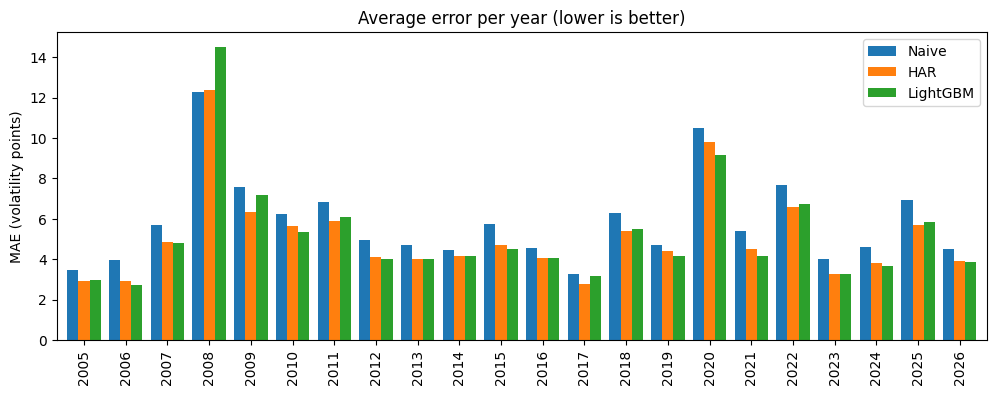

In [72]:
yearly = errors.groupby(errors.index.year).mean()                # average error of each model, per year

ax = yearly.plot(kind="bar", figsize=(12, 4), width=0.8,
                 title="Average error per year (lower is better)")   # one group of 3 bars per year
ax.set_ylabel("MAE (volatility points)")                         # label the vertical axis
ax.set_xlabel("")                                                # the years explain themselves
plt.show()

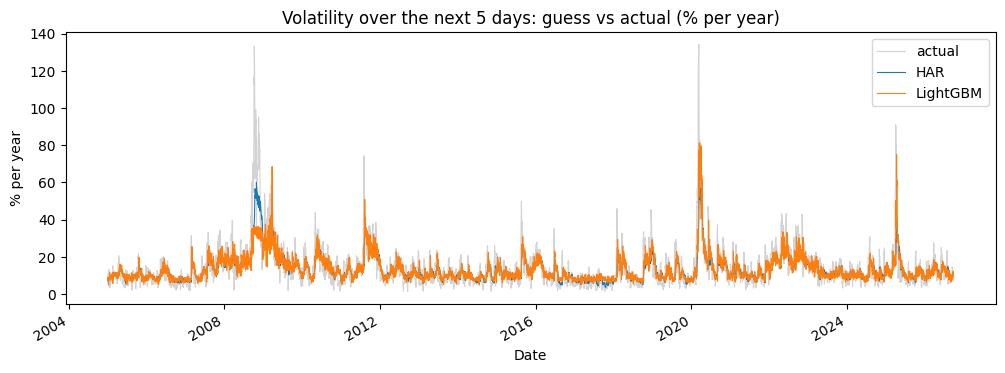

In [73]:
ax = preds_pct["actual"].plot(figsize=(12, 4), color="lightgrey", linewidth=0.8,
                              label="actual")                    # what really happened, in light grey
preds_pct["HAR"].plot(ax=ax, linewidth=0.8, label="HAR")         # HAR's guesses, on the same axes
preds_pct["LightGBM"].plot(ax=ax, linewidth=0.8, label="LightGBM")   # LightGBM's guesses
ax.set_title("Volatility over the next 5 days: guess vs actual (% per year)")
ax.set_ylabel("% per year")
ax.legend()                                                      # show which line is which
plt.show()

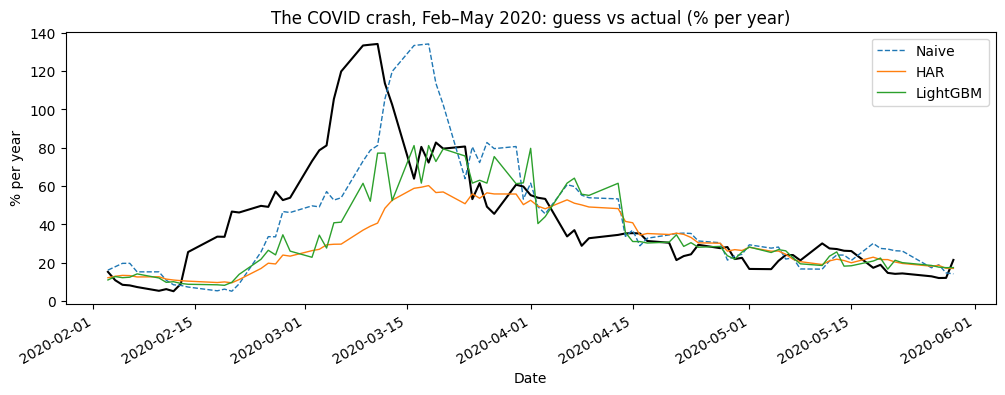

In [74]:
crash = preds_pct.loc["2020-02-01":"2020-05-31"]                 # February to May 2020 only

ax = crash["actual"].plot(figsize=(12, 4), color="black", linewidth=1.5,
                          label="actual")                        # the truth, bold
crash[names].plot(ax=ax, linewidth=1, style=["--", "-", "-"])    # Naive dashed, HAR and LightGBM solid
ax.set_title("The COVID crash, Feb–May 2020: guess vs actual (% per year)")
ax.set_ylabel("% per year")
plt.show()
